In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

from matplotlib import rc
rc('font', size=20)

In [6]:
import energyflow as ef

In [7]:
datasets = {'Pythia26': ef.zjets_delphes.load('Pythia26', num_data=1000000,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Pythia25': ef.zjets_delphes.load('Pythia25', num_data=1000000,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Pythia21': ef.zjets_delphes.load('Pythia21', num_data=1000000,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Herwig': ef.zjets_delphes.load('Herwig', num_data=1000000,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold")}

<__array_function__ internals>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


In [8]:
datasets['Pythia26'].keys()

dict_keys(['gen_particles', 'gen_tau2s', 'gen_widths', 'gen_Zs', 'gen_mults', 'gen_ang2s', 'gen_lhas', 'gen_zgs', 'gen_sdms', 'gen_jets', 'sim_particles', 'sim_tau2s', 'sim_widths', 'sim_mults', 'sim_ang2s', 'sim_lhas', 'sim_zgs', 'sim_sdms', 'sim_jets'])

In [9]:
w_true_mc = datasets['Pythia21']['gen_widths']
w_reco_mc = datasets['Pythia21']['sim_widths']
w_true_mc_systup = datasets['Pythia25']['gen_widths']
w_reco_mc_systup = datasets['Pythia25']['sim_widths']
w_true_mc_systdn = datasets['Pythia26']['gen_widths']
w_reco_mc_systdn = datasets['Pythia26']['sim_widths']
w_true_data = datasets['Herwig']['gen_widths']
w_reco_data = datasets['Herwig']['sim_widths']

In [10]:
#For the binning, make it so we have 50% in each bin growing from the low side
binvals = [0]
i = 0
while binvals[-1] < 1:
    for binhigh in np.linspace(binvals[-1]+0.01,1.1,20):
        purity = len(w_true_mc[(w_true_mc > binvals[i])*(w_true_mc < binhigh)*(w_reco_mc > binvals[i])*(w_reco_mc < binhigh)]) / len(w_true_mc[(w_true_mc > binvals[i])*(w_true_mc < binhigh)])
        if (purity > 0.5**0.5):
            print(binhigh,purity)
            i+=1
            binvals+=[binhigh]
            break
        elif (binhigh > 1):
            print(binhigh,purity)
            binvals+=[binhigh]
            break

0.12473684210526316 0.8095569387888532
0.23634349030470914 0.8072898281285545
0.3362020702726345 0.754457400894254
0.4255492207702519 0.7193767355754397
0.5404625017012648 0.7210440456769984
1.0132309213212525 0.4609595484477893


In [11]:
#Next, let's construct the response matrix.

wbin_truth = np.clip(np.digitize(w_true_mc,binvals),1,len(binvals)-1)-1
wbin_reco = np.clip(np.digitize(w_reco_mc,binvals),1,len(binvals)-1)-1
H_pT, xedges, yedges = np.histogram2d(wbin_truth,wbin_reco,bins=[range(len(binvals)),range(len(binvals))])

#data
wbin_truth_data = np.clip(np.digitize(w_true_data,binvals),1,len(binvals)-1)-1
wbin_reco_data = np.clip(np.digitize(w_reco_data,binvals),1,len(binvals)-1)-1
H_pT_data, _, _ = np.histogram2d(wbin_truth_data,wbin_reco_data,bins=[range(len(binvals)),range(len(binvals))])

#up
wbin_truth_systup = np.clip(np.digitize(w_true_mc_systup,binvals),1,len(binvals)-1)-1
wbin_reco_systup = np.clip(np.digitize(w_reco_mc_systup,binvals),1,len(binvals)-1)-1
H_pT_systup, _, _ = np.histogram2d(wbin_truth_systup,wbin_reco_systup,bins=[range(len(binvals)),range(len(binvals))])

#dn
wbin_truth_systdn = np.clip(np.digitize(w_true_mc_systdn,binvals),1,len(binvals)-1)-1
wbin_reco_systdn = np.clip(np.digitize(w_reco_mc_systdn,binvals),1,len(binvals)-1)-1
H_pT_systdn, _, _ = np.histogram2d(wbin_truth_systdn,wbin_reco_systdn,bins=[range(len(binvals)),range(len(binvals))])

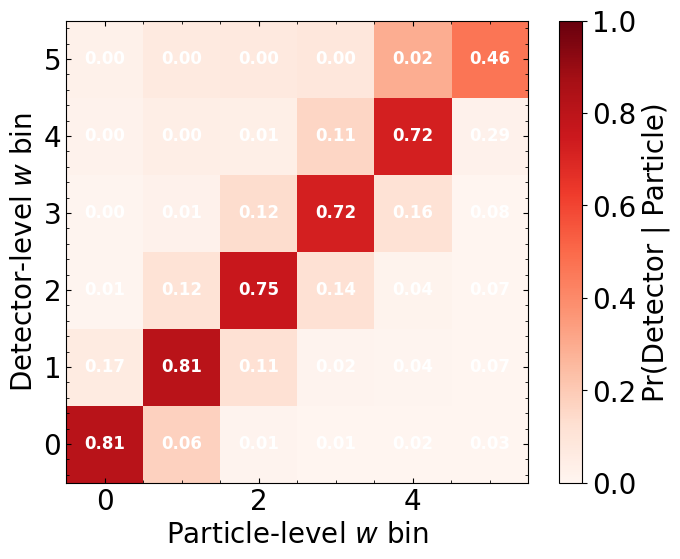

In [12]:
fig = plt.figure(figsize=(8, 6)) 
gs = gridspec.GridSpec(1, 1, height_ratios=[1]) 
ax0 = plt.subplot(gs[0])
ax0.yaxis.set_ticks_position('both')
ax0.xaxis.set_ticks_position('both')
ax0.tick_params(direction="in",which="both")
ax0.minorticks_on()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

H_norm_pT = H_pT / H_pT.sum(axis=1, keepdims=True)
plt.imshow(H_norm_pT,origin='lower',cmap="Reds",vmin = 0,vmax = 1)
cbar = plt.colorbar()
cbar.ax.set_ylabel('Pr(Detector | Particle)',fontsize=20) 
plt.xlabel("Particle-level $w$ bin",fontsize=20)
plt.ylabel("Detector-level $w$ bin",fontsize=20)

for i in range(len(binvals)-1):
    for j2 in range(len(binvals)-1):
        plt.text(j2,i, "%0.2f" % H_norm_pT.T[i,j2], 
                color="w", ha="center", va="center", fontweight="bold",fontsize=12)
#fig.savefig('figures/Rsponsew.pdf',bbox_inches='tight')

In [13]:
def IBU(T,D,R,n):
    phis = [T]
    for i in range(n):
        m = R * phis[-1]
        m /= (m.sum(axis=1)[:,np.newaxis] + 10**-50)
        phis.append(np.dot(m.T, D))
    return phis[-1]

In [10]:
T_mc = np.sum(H_pT,axis=1)
D_mc = np.sum(H_pT,axis=0)
IBU(T_mc,D_mc,H_norm_pT.T,5)-T_mc

T_data = np.sum(H_pT_data,axis=1)
D_data = np.sum(H_pT_data,axis=0)
(IBU(T_mc,D_data,H_norm_pT.T,5)-T_data)/T_data

T_mc_systup = np.sum(H_pT_systup,axis=1)
D_mc_systup = np.sum(H_pT_systup,axis=0)

T_mc_systdn = np.sum(H_pT_systdn,axis=1)
D_mc_systdn = np.sum(H_pT_systdn,axis=0)

In [12]:
#Prior uncertainty would normally come from trying different priors.  
#This could include a data-like prior ('data-driven non-closure test') as well as ones from alternative MCs.

In [13]:
print((IBU(T_mc,D_data,H_norm_pT.T,5)-T_data)/T_data)
print((IBU(T_mc_systup,D_data,H_norm_pT.T,5)-T_data)/T_data)
print((IBU(T_mc_systdn,D_data,H_norm_pT.T,5)-T_data)/T_data)

[-0.00829188  0.01068169  0.00321757  0.00574665  0.02645519  0.07569739]
[-0.0102787   0.01635817 -0.00175338  0.00544473  0.02369129  0.14439145]
[-0.00529233  0.00212339  0.01064641  0.0066818   0.02913888 -0.01665684]
